Validation table

In [3]:
import pandas as pd

summary_df = pd.read_pickle("summary_df.pkl")

In [4]:
print(summary_df.columns.tolist())
print(summary_df.head(10).to_string())

['patient_id', 'dataset', 'input_type', 'model', 'model_group', 'metric_row', 'metric_col', 'weighted_f1', 'filename', 'filepath']
  patient_id dataset input_type model     model_group    metric_row metric_col  weighted_f1                                                                           filename                                                                                                                                                                                        filepath
0      10OXG    Test   FEATURES   SVM  FEATURES + SVM  weighted avg   f1-score     0.810780  10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_20260612_v01_Test_classification_table.csv  /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/classification_tables/10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_20260612_v01_Test_classification_table.csv
1      1JSZ6    Test   FEATURES   SVM  FEATURES + SVM  weighted avg   f1-score     0.752007  1JSZ6_IN-FEATURES_SVM-SCORING-F1-MACRO_202

In [6]:
from pathlib import Path
import pandas as pd


def read_classification_report(filepath):
    """Read a saved sklearn-style classification report."""
    report_df = pd.read_csv(filepath, index_col=0)

    report_df.index = (
        report_df.index
        .astype(str)
        .str.strip()
        .str.lower()
    )

    report_df.columns = (
        report_df.columns
        .astype(str)
        .str.strip()
        .str.lower()
    )

    return report_df


def find_report_row(report_df, possible_names):
    """Find a classification-report row using several possible labels."""
    for name in possible_names:
        name = str(name).strip().lower()

        if name in report_df.index:
            return name

    raise KeyError(
        f"None of the expected rows {possible_names} were found. "
        f"Available rows: {report_df.index.tolist()}"
    )


# ------------------------------------------------------------------
# 1. Separate validation and test results
# ------------------------------------------------------------------

dataset_normalized = summary_df["dataset"].astype(str).str.strip().str.lower()

validation_df = summary_df[
    dataset_normalized.isin(["validation", "val"])
].copy()

test_df = summary_df[
    dataset_normalized.eq("test")
].copy()


# ------------------------------------------------------------------
# 2. Select the best configuration using validation weighted F1
# ------------------------------------------------------------------

best_validation_idx = (
    validation_df
    .groupby("patient_id", observed=True)["weighted_f1"]
    .idxmax()
)

selected_validation_df = (
    validation_df.loc[
        best_validation_idx,
        ["patient_id", "model_group", "weighted_f1"]
    ]
    .rename(
        columns={
            "model_group": "Configuration selected by validation",
            "weighted_f1": "Validation weighted F1",
        }
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------
# 3. Add the matching test result for the selected configuration
# ------------------------------------------------------------------

selected_results_df = selected_validation_df.merge(
    test_df[
        [
            "patient_id",
            "model_group",
            "weighted_f1",
            "filepath",
        ]
    ],
    left_on=[
        "patient_id",
        "Configuration selected by validation",
    ],
    right_on=[
        "patient_id",
        "model_group",
    ],
    how="left",
    validate="one_to_one",
)


# ------------------------------------------------------------------
# 4. Extract test accuracy and class-specific F1 scores
# ------------------------------------------------------------------

test_metrics = []

for _, row in selected_results_df.iterrows():

    if pd.isna(row["filepath"]):
        raise FileNotFoundError(
            f"No matching test file was found for patient "
            f"{row['patient_id']} and configuration "
            f"{row['Configuration selected by validation']}."
        )

    report_df = read_classification_report(row["filepath"])

    accuracy_row = find_report_row(
        report_df,
        ["accuracy"]
    )

    preictal_row = find_report_row(
        report_df,
        ["preictal", "class 0", "0"]
    )

    ictal_row = find_report_row(
        report_df,
        ["ictal", "seizure", "class 1", "1"]
    )

    test_metrics.append(
        {
            "Test accuracy": report_df.loc[accuracy_row, "f1-score"],
            "Test preictal F1": report_df.loc[preictal_row, "f1-score"],
            "Test ictal F1": report_df.loc[ictal_row, "f1-score"],
        }
    )

test_metrics_df = pd.DataFrame(test_metrics)


# ------------------------------------------------------------------
# 5. Create the final dataframe
# ------------------------------------------------------------------

final_model_summary_df = pd.concat(
    [
        selected_results_df.reset_index(drop=True),
        test_metrics_df,
    ],
    axis=1,
)

final_model_summary_df = (
    final_model_summary_df.rename(
        columns={
            "patient_id": "Patient ID",
            "weighted_f1": "Test weighted F1",
        }
    )
    [
        [
            "Patient ID",
            "Configuration selected by validation",
            "Validation weighted F1",
            "Test accuracy",
            "Test weighted F1",
            "Test preictal F1",
            "Test ictal F1",
        ]
    ]
    .sort_values("Patient ID")
    .reset_index(drop=True)
)

final_model_summary_df

,Patient ID,Configuration selected by validation,Validation weighted F1,Test accuracy,Test weighted F1,Test preictal F1,Test ictal F1
0,10OXG,PCA + Decision Tree,0.657733,0.801802,0.797321,0.765957,0.828125
1,1JSZ6,PCA + Random Forest,0.879566,0.878261,0.876575,0.860000,0.892308
2,3ZL8B,FEATURES + SVM,0.823423,0.750000,0.748718,0.766667,0.730769
3,F88R2,PCA + SVM,0.787784,0.808824,0.804657,0.831169,0.779661
4,FP628,FEATURES + SVM,0.908030,0.876471,0.876224,0.860927,0.888889
5,JYXFE,FEATURES + SVM,0.519451,0.309091,0.306342,0.344828,0.269231
6,PN12G,FEATURES + SVM,0.691832,0.739130,0.738775,0.745763,0.732143
7,RQXZ1,PCA + Random Forest,0.502674,0.520325,0.501231,0.594966,0.411960
8,XB47Y,PCA + Decision Tree,0.715272,0.547945,0.548810,0.476190,0.602410


In [7]:
study_label_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9",
}

final_model_summary_df.insert(
    0,
    "Study label",
    final_model_summary_df["Patient ID"].map(study_label_map)
)

study_label_order = [f"P{i}" for i in range(1, 10)]

final_model_summary_df["Study label"] = pd.Categorical(
    final_model_summary_df["Study label"],
    categories=study_label_order,
    ordered=True
)

final_model_summary_df = (
    final_model_summary_df
    .sort_values("Study label")
    .reset_index(drop=True)
)

final_model_summary_df

,Study label,Patient ID,Configuration selected by validation,Validation weighted F1,Test accuracy,Test weighted F1,Test preictal F1,Test ictal F1
0,P1,10OXG,PCA + Decision Tree,0.657733,0.801802,0.797321,0.765957,0.828125
1,P2,1JSZ6,PCA + Random Forest,0.879566,0.878261,0.876575,0.860000,0.892308
2,P3,3ZL8B,FEATURES + SVM,0.823423,0.750000,0.748718,0.766667,0.730769
3,P4,F88R2,PCA + SVM,0.787784,0.808824,0.804657,0.831169,0.779661
4,P5,FP628,FEATURES + SVM,0.908030,0.876471,0.876224,0.860927,0.888889
5,P6,JYXFE,FEATURES + SVM,0.519451,0.309091,0.306342,0.344828,0.269231
6,P7,PN12G,FEATURES + SVM,0.691832,0.739130,0.738775,0.745763,0.732143
7,P8,RQXZ1,PCA + Random Forest,0.502674,0.520325,0.501231,0.594966,0.411960
8,P9,XB47Y,PCA + Decision Tree,0.715272,0.547945,0.548810,0.476190,0.602410


In [8]:
from pathlib import Path

output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/"
    "Main_project/results/together_results/summary_tables"
)

output_dir.mkdir(parents=True, exist_ok=True)

excel_output_path = output_dir / "final_model_summary_table.xlsx"

final_model_summary_df.to_excel(
    excel_output_path,
    index=False
)

print(f"Saved to: {excel_output_path}")

Saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_tables/final_model_summary_table.xlsx


In [9]:
from pathlib import Path
import pandas as pd

# ============================================================
# 1. Define paths
# ============================================================

project_root = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026"
)

mra_dir = (
    project_root
    / "Main_project/results/together_results/MRA"
)

summary_tables_dir = (
    project_root
    / "Main_project/results/together_results/summary_tables"
)

summary_tables_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. Load dataset characteristics
# ============================================================

df_characteristics = pd.read_csv(
    mra_dir / "dataset_characteristics.csv"
)


# ============================================================
# 3. Load patient feature summary table
# ============================================================

thesis_table = pd.read_pickle(
    summary_tables_dir / "patient_feature_summary_table.pkl"
)


# ============================================================
# 4. Standardise Patient ID columns
# ============================================================

df_characteristics = df_characteristics.rename(
    columns={
        "patient_id": "Patient ID",
        "Patient_ID": "Patient ID",
    }
)

thesis_table = thesis_table.rename(
    columns={
        "patient_id": "Patient ID",
        "Patient_ID": "Patient ID",
    }
)


# ============================================================
# 5. Standardise significant-feature column name
# ============================================================

if "prop_significant_features" not in thesis_table.columns:
    raise KeyError(
        "'prop_significant_features' was not found in "
        "patient_feature_summary_table.pkl.\n"
        f"Available columns: {thesis_table.columns.tolist()}"
    )

thesis_table = thesis_table.rename(
    columns={
        "prop_significant_features": "Significant features (%)"
    }
)


# ============================================================
# 6. Avoid duplicated Study label columns
# ============================================================

df_characteristics = df_characteristics.drop(
    columns=["Study label"],
    errors="ignore"
)


# ============================================================
# 7. Merge characteristics with validation-selected models
# ============================================================

final_merged_df = final_model_summary_df.merge(
    df_characteristics,
    on="Patient ID",
    how="left",
    validate="one_to_one"
)


# ============================================================
# 8. Add significant features percentage
# ============================================================

# Prefer Patient ID as the merge key
if "Patient ID" in thesis_table.columns:

    feature_summary_for_merge = (
        thesis_table[
            [
                "Patient ID",
                "Significant features (%)",
            ]
        ]
        .drop_duplicates(subset="Patient ID")
        .copy()
    )

    final_merged_df = final_merged_df.merge(
        feature_summary_for_merge,
        on="Patient ID",
        how="left",
        validate="one_to_one"
    )

# Fall back to Study label if Patient ID is not present
elif "Study label" in thesis_table.columns:

    feature_summary_for_merge = (
        thesis_table[
            [
                "Study label",
                "Significant features (%)",
            ]
        ]
        .drop_duplicates(subset="Study label")
        .copy()
    )

    final_merged_df = final_merged_df.merge(
        feature_summary_for_merge,
        on="Study label",
        how="left",
        validate="one_to_one"
    )

else:
    raise KeyError(
        "The feature-summary table contains neither "
        "'Patient ID' nor 'Study label'."
    )


# ============================================================
# 9. Select and order final columns
# ============================================================

final_merged_df = final_merged_df[
    [
        "Study label",
        "Patient ID",
        "sqEEG recorded (h)",
        "Seizures, n",
        "Recording duration, days",
        "Seizure density",
        "Data capture rate, h/day",
        "Data capture rate, %",
        "Significant features (%)",
        "Configuration selected by validation",
        "Validation weighted F1",
        "Test accuracy",
        "Test weighted F1",
        "Test preictal F1",
        "Test ictal F1",
    ]
]


# ============================================================
# 10. Order patients from P1 to P9
# ============================================================

study_label_order = [
    "P1", "P2", "P3", "P4", "P5",
    "P6", "P7", "P8", "P9"
]

final_merged_df["Study label"] = pd.Categorical(
    final_merged_df["Study label"],
    categories=study_label_order,
    ordered=True
)

final_merged_df = (
    final_merged_df
    .sort_values("Study label")
    .reset_index(drop=True)
)


# ============================================================
# 11. Convert and round numerical results
# ============================================================

columns_to_round_3 = [
    "Seizure density",
    "Data capture rate, h/day",
    "Data capture rate, %",
    "Validation weighted F1",
    "Test accuracy",
    "Test weighted F1",
    "Test preictal F1",
    "Test ictal F1",
]

final_merged_df[columns_to_round_3] = (
    final_merged_df[columns_to_round_3]
    .apply(pd.to_numeric, errors="coerce")
    .round(3)
)

# Preserve the percentage style used in the thesis table
final_merged_df["Significant features (%)"] = (
    pd.to_numeric(
        final_merged_df["Significant features (%)"],
        errors="coerce"
    )
    .round(1)
)


# ============================================================
# 12. Check for unmatched significant-feature values
# ============================================================

missing_significant_features = final_merged_df.loc[
    final_merged_df["Significant features (%)"].isna(),
    ["Study label", "Patient ID"]
]

if not missing_significant_features.empty:
    print(
        "Warning: significant-feature values were not found "
        "for these patients:"
    )
    print(missing_significant_features.to_string(index=False))


# ============================================================
# 13. Export final merged dataframe as PKL
# ============================================================

output_path = summary_tables_dir / "totalValmerged.pkl"

final_merged_df.to_pickle(output_path)

print(f"PKL saved to: {output_path}")
print(f"Final shape: {final_merged_df.shape}")

final_merged_df

PKL saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_tables/totalValmerged.pkl
Final shape: (9, 15)


,Study label,Patient ID,sqEEG recorded (h),"Seizures, n","Recording duration, days",Seizure density,"Data capture rate, h/day","Data capture rate, %",Significant features (%),Configuration selected by validation,Validation weighted F1,Test accuracy,Test weighted F1,Test preictal F1,Test ictal F1
0,P1,10OXG,6943,56,506,0.19,13.7,57.2,82.1,PCA + Decision Tree,0.658,0.802,0.797,0.766,0.828
1,P2,1JSZ6,9472,63,417,0.16,22.8,95.0,71.4,PCA + Random Forest,0.880,0.878,0.877,0.860,0.892
2,P3,3ZL8B,11692,54,538,0.11,21.7,90.5,67.9,FEATURES + SVM,0.823,0.750,0.749,0.767,0.731
3,P4,F88R2,4941,33,241,0.16,20.5,85.4,78.6,PCA + SVM,0.788,0.809,0.805,0.831,0.780
4,P5,FP628,9319,92,495,0.24,18.8,78.4,89.3,FEATURES + SVM,0.908,0.876,0.876,0.861,0.889
5,P6,JYXFE,3620,31,433,0.21,8.4,34.8,21.4,FEATURES + SVM,0.519,0.309,0.306,0.345,0.269
6,P7,PN12G,10363,132,438,0.31,23.7,98.6,82.1,FEATURES + SVM,0.692,0.739,0.739,0.746,0.732
7,P8,RQXZ1,2783,203,263,1.75,10.6,44.1,53.6,PCA + Random Forest,0.503,0.520,0.501,0.595,0.412
8,P9,XB47Y,809,36,45,1.07,17.9,74.7,78.6,PCA + Decision Tree,0.715,0.548,0.549,0.476,0.602


## Multiple regression analysis 

Pearson correlation between data capture rate and validation-selected test accuracy:
r = 0.749, p = 0.020


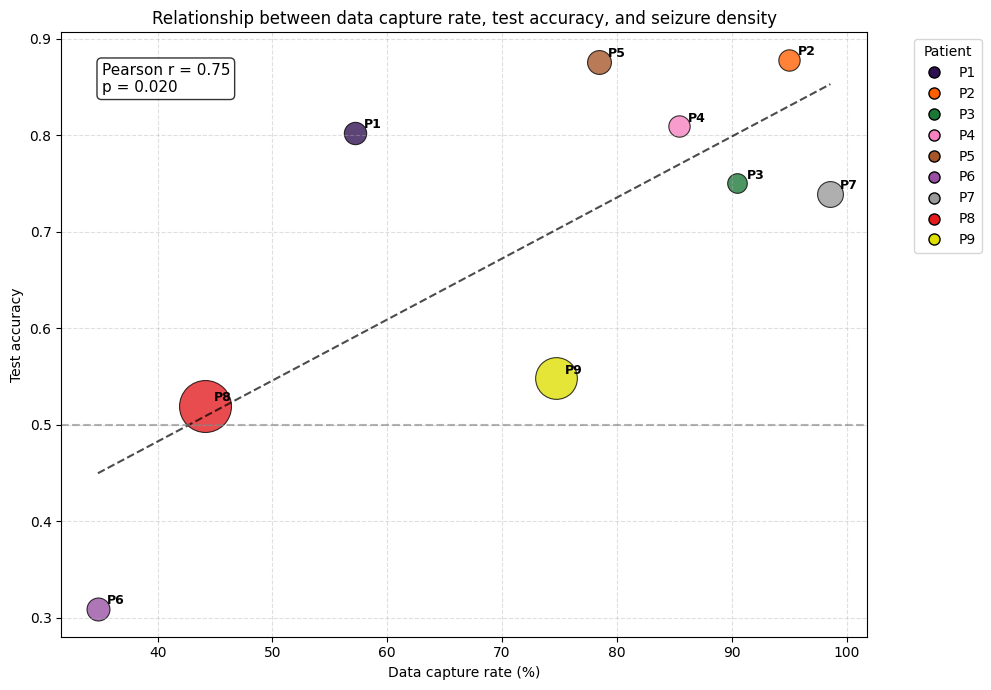

SVG saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/MRA/bubble_data_capture_test_accuracy_pearson_2026-07-12.svg


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import date

# ============================================================
# Bubble scatter plot
# X = Data capture rate (%)
# Y = Test accuracy from the configuration selected by validation
# Bubble size = Seizure density
# Colour = Patient number
# Label = Patient number
# + Pearson correlation
# ============================================================

patient_number_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9"
}

patient_order = [
    "P1", "P2", "P3", "P4", "P5",
    "P6", "P7", "P8", "P9"
]

CB_color_cycle = [
    "#2E0F4F",  # P1 - very dark violet
    "#FF5F00",  # P2 - very bright orange
    "#1B7837",  # P3 - dark green
    "#f781bf",  # P4 - pink
    "#a65628",  # P5 - brown
    "#984ea3",  # P6 - purple
    "#999999",  # P7 - grey
    "#e41a1c",  # P8 - red
    "#dede00"   # P9 - yellow
]

patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

# final_merged_df contains the test metrics corresponding to
# the configuration selected using validation weighted F1
df_plot = final_merged_df.copy()

# ============================================================
# Prepare columns
# ============================================================

numeric_columns = [
    "Data capture rate, %",
    "Test accuracy",
    "Seizure density"
]

df_plot[numeric_columns] = df_plot[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Use the existing Study label when available
if "Study label" in df_plot.columns:
    df_plot["Patient"] = df_plot["Study label"].astype(str)
else:
    df_plot["Patient"] = df_plot["Patient ID"].map(patient_number_map)

# Keep only complete rows
df_plot = df_plot.dropna(
    subset=[
        "Patient ID",
        "Patient",
        "Data capture rate, %",
        "Test accuracy",
        "Seizure density"
    ]
).copy()

# Check for unmapped patients
unmapped_patients = df_plot.loc[
    ~df_plot["Patient"].isin(patient_order),
    "Patient ID"
].unique()

if len(unmapped_patients) > 0:
    print("Warning: these Patient IDs were not mapped:", unmapped_patients)

df_plot = df_plot[df_plot["Patient"].isin(patient_order)].copy()

# Sort from P1 to P9
df_plot["Patient"] = pd.Categorical(
    df_plot["Patient"],
    categories=patient_order,
    ordered=True
)

df_plot = (
    df_plot
    .sort_values("Patient")
    .reset_index(drop=True)
)

# ============================================================
# Pearson correlation:
# Data capture rate vs validation-selected test accuracy
# ============================================================

x = df_plot["Data capture rate, %"]
y = df_plot["Test accuracy"]

pearson_r, pearson_p = pearsonr(x, y)

print(
    "Pearson correlation between data capture rate and "
    "validation-selected test accuracy:"
)
print(f"r = {pearson_r:.3f}, p = {pearson_p:.3f}")

# ============================================================
# Bubble size scaling
# matplotlib 's' represents marker area
# ============================================================

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = pd.Series(
        600,
        index=df_plot.index
    )
else:
    bubble_sizes = 200 + (
        (density - density.min())
        / (density.max() - density.min())
    ) * 1200

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

for i, row in df_plot.iterrows():

    ax.scatter(
        row["Data capture rate, %"],
        row["Test accuracy"],
        s=bubble_sizes.loc[i],
        color=patient_colors[row["Patient"]],
        alpha=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    ax.text(
        row["Data capture rate, %"] + 0.8,
        row["Test accuracy"] + 0.005,
        row["Patient"],
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# Linear trend line
# ============================================================

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    200
)

ax.plot(
    x_line,
    m * x_line + b,
    linestyle="--",
    color="black",
    alpha=0.7
)

# ============================================================
# Correlation annotation
# ============================================================

ax.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)

ax.set_xlabel("Data capture rate (%)")
ax.set_ylabel("Test accuracy")

ax.set_title(
    "Relationship between data capture rate, test accuracy, "
    "and seizure density"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

# Chance-level reference line
ax.axhline(
    0.5,
    linestyle="--",
    color="grey",
    alpha=0.6
)

# ============================================================
# Patient colour legend
# ============================================================

patients_present = df_plot["Patient"].astype(str).unique()

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in patient_order
    if patient in patients_present
]

ax.legend(
    handles=legend_handles,
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# ============================================================
# Save as SVG in the MRA results folder
# ============================================================

output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/"
    "Main_project/results/together_results/MRA"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

today = date.today().strftime("%Y-%m-%d")

output_path = (
    output_dir
    / f"bubble_data_capture_test_accuracy_pearson_{today}.svg"
)

plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print(f"SVG saved to: {output_path.resolve()}")

Pearson correlation between significant features (%) and validation-selected test accuracy:
r = 0.838, p = 0.005


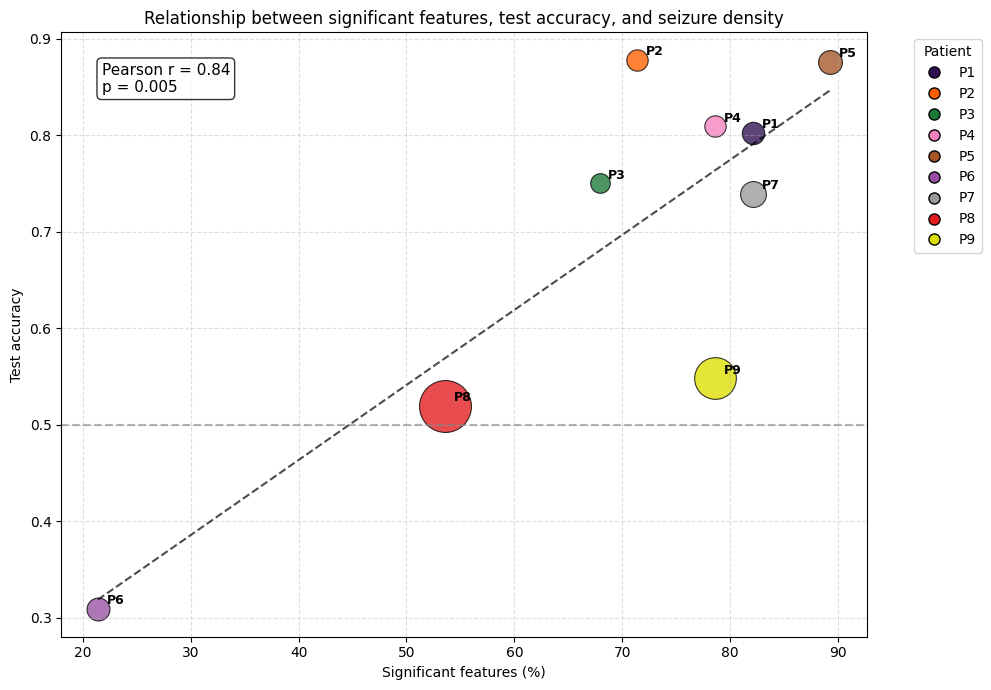

SVG saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/MRA/bubble_significant_features_test_accuracy_pearson_2026-07-12.svg


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import date

# ============================================================
# Bubble scatter plot
# X = Significant features (%)
# Y = Test accuracy from the configuration selected by validation
# Bubble size = Seizure density
# Colour = Patient number
# Label = Patient number
# + Pearson correlation
# ============================================================

patient_number_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9"
}

patient_order = [
    "P1", "P2", "P3", "P4", "P5",
    "P6", "P7", "P8", "P9"
]

CB_color_cycle = [
    "#2E0F4F",  # P1
    "#FF5F00",  # P2
    "#1B7837",  # P3
    "#f781bf",  # P4
    "#a65628",  # P5
    "#984ea3",  # P6
    "#999999",  # P7
    "#e41a1c",  # P8
    "#dede00"   # P9
]

patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

# Contains test results for the configuration selected by validation
df_plot = final_merged_df.copy()

# ============================================================
# Prepare columns
# ============================================================

numeric_columns = [
    "Significant features (%)",
    "Test accuracy",
    "Seizure density"
]

df_plot[numeric_columns] = df_plot[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Convert proportions to percentages only if necessary
if df_plot["Significant features (%)"].max() <= 1:
    df_plot["Significant features (%)"] *= 100

# Use Study label when available
if "Study label" in df_plot.columns:
    df_plot["Patient"] = df_plot["Study label"].astype(str)
else:
    df_plot["Patient"] = df_plot["Patient ID"].map(patient_number_map)

# Keep complete rows
df_plot = df_plot.dropna(
    subset=[
        "Patient ID",
        "Patient",
        "Significant features (%)",
        "Test accuracy",
        "Seizure density"
    ]
).copy()

# Check for unmapped patients
unmapped_patients = df_plot.loc[
    ~df_plot["Patient"].isin(patient_order),
    "Patient ID"
].unique()

if len(unmapped_patients) > 0:
    print("Warning: these Patient IDs were not mapped:", unmapped_patients)

df_plot = df_plot[
    df_plot["Patient"].isin(patient_order)
].copy()

# Sort P1–P9
df_plot["Patient"] = pd.Categorical(
    df_plot["Patient"],
    categories=patient_order,
    ordered=True
)

df_plot = (
    df_plot
    .sort_values("Patient")
    .reset_index(drop=True)
)

# ============================================================
# Pearson correlation:
# Significant features (%) vs test accuracy
# ============================================================

x = df_plot["Significant features (%)"]
y = df_plot["Test accuracy"]

pearson_r, pearson_p = pearsonr(x, y)

print(
    "Pearson correlation between significant features (%) "
    "and validation-selected test accuracy:"
)
print(f"r = {pearson_r:.3f}, p = {pearson_p:.3f}")

# ============================================================
# Bubble size scaling
# ============================================================

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = pd.Series(
        600,
        index=df_plot.index
    )
else:
    bubble_sizes = 200 + (
        (density - density.min())
        / (density.max() - density.min())
    ) * 1200

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

for i, row in df_plot.iterrows():

    ax.scatter(
        row["Significant features (%)"],
        row["Test accuracy"],
        s=bubble_sizes.loc[i],
        color=patient_colors[row["Patient"]],
        alpha=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    ax.text(
        row["Significant features (%)"] + 0.8,
        row["Test accuracy"] + 0.005,
        row["Patient"],
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# Linear trend line
# ============================================================

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    200
)

ax.plot(
    x_line,
    m * x_line + b,
    linestyle="--",
    color="black",
    alpha=0.7
)

# ============================================================
# Correlation annotation
# ============================================================

ax.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)

ax.set_xlabel("Significant features (%)")
ax.set_ylabel("Test accuracy")

ax.set_title(
    "Relationship between significant features, test accuracy, "
    "and seizure density"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

# Chance-level reference line
ax.axhline(
    0.5,
    linestyle="--",
    color="grey",
    alpha=0.6
)

# ============================================================
# Patient legend
# ============================================================

patients_present = df_plot["Patient"].astype(str).unique()

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in patient_order
    if patient in patients_present
]

ax.legend(
    handles=legend_handles,
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# ============================================================
# Save as SVG in MRA results folder
# ============================================================

output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/"
    "Main_project/results/together_results/MRA"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

today = date.today().strftime("%Y-%m-%d")

output_path = (
    output_dir
    / f"bubble_significant_features_test_accuracy_pearson_{today}.svg"
)

plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print(f"SVG saved to: {output_path.resolve()}")

Pearson correlation between data capture rate and significant features (%):
r = 0.704, p = 0.034


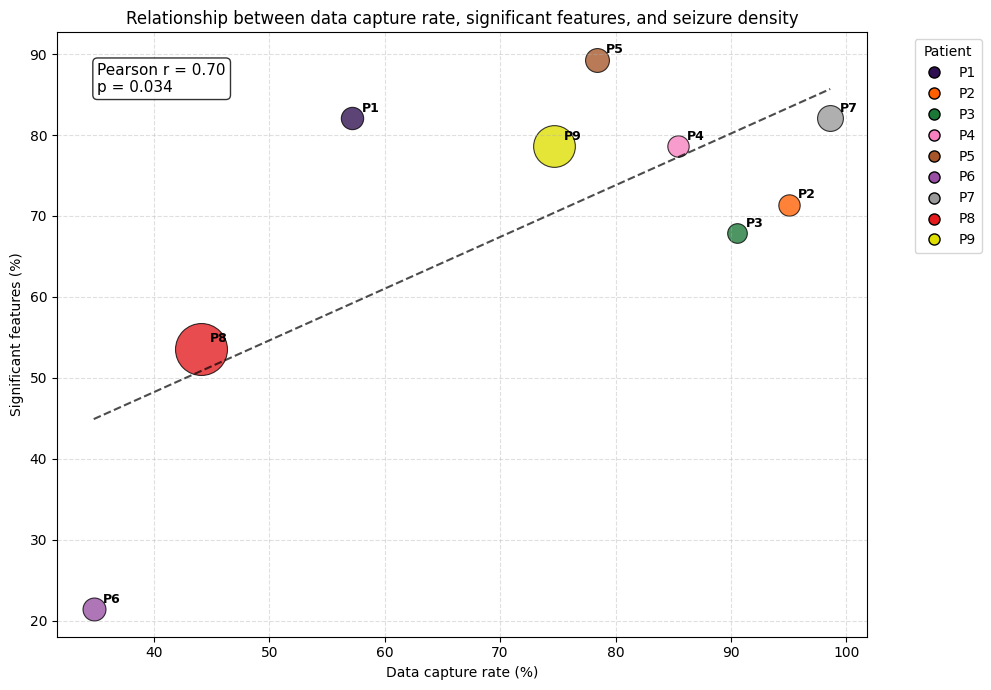

SVG saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/MRA/bubble_data_capture_significant_features_pearson_2026-07-12.svg


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import date

# ============================================================
# Bubble scatter plot
# X = Data capture rate (%)
# Y = Significant features (%)
# Bubble size = Seizure density
# Colour and label = Patient number
# + Pearson correlation
# ============================================================

patient_order = [
    "P1", "P2", "P3", "P4", "P5",
    "P6", "P7", "P8", "P9"
]

CB_color_cycle = [
    "#2E0F4F",  # P1
    "#FF5F00",  # P2
    "#1B7837",  # P3
    "#f781bf",  # P4
    "#a65628",  # P5
    "#984ea3",  # P6
    "#999999",  # P7
    "#e41a1c",  # P8
    "#dede00"   # P9
]

patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

df_plot = final_merged_df.copy()

# ============================================================
# Prepare columns
# ============================================================

numeric_columns = [
    "Data capture rate, %",
    "Significant features (%)",
    "Seizure density"
]

df_plot[numeric_columns] = df_plot[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# In case significant features are stored as proportions (0–1),
# convert them to percentages (0–100)
if df_plot["Significant features (%)"].max() <= 1:
    df_plot["Significant features (%)"] *= 100

df_plot["Patient"] = df_plot["Study label"].astype(str)

df_plot = df_plot.dropna(
    subset=[
        "Patient",
        "Data capture rate, %",
        "Significant features (%)",
        "Seizure density"
    ]
).copy()

df_plot = df_plot[
    df_plot["Patient"].isin(patient_order)
].copy()

df_plot["Patient"] = pd.Categorical(
    df_plot["Patient"],
    categories=patient_order,
    ordered=True
)

df_plot = (
    df_plot
    .sort_values("Patient")
    .reset_index(drop=True)
)

# ============================================================
# Pearson correlation
# ============================================================

x = df_plot["Data capture rate, %"]
y = df_plot["Significant features (%)"]

pearson_r, pearson_p = pearsonr(x, y)

print(
    "Pearson correlation between data capture rate and "
    "significant features (%):"
)
print(f"r = {pearson_r:.3f}, p = {pearson_p:.3f}")

# ============================================================
# Bubble size scaling
# ============================================================

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = pd.Series(600, index=df_plot.index)
else:
    bubble_sizes = 200 + (
        (density - density.min())
        / (density.max() - density.min())
    ) * 1200

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

for i, row in df_plot.iterrows():

    patient = row["Patient"]

    ax.scatter(
        row["Data capture rate, %"],
        row["Significant features (%)"],
        s=bubble_sizes.loc[i],
        color=patient_colors[patient],
        alpha=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    ax.text(
        row["Data capture rate, %"] + 0.8,
        row["Significant features (%)"] + 0.8,
        patient,
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# Linear trend line
# ============================================================

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    200
)

ax.plot(
    x_line,
    m * x_line + b,
    linestyle="--",
    color="black",
    alpha=0.7
)

# ============================================================
# Correlation annotation
# ============================================================

ax.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

ax.set_xlabel("Data capture rate (%)")
ax.set_ylabel("Significant features (%)")

ax.set_title(
    "Relationship between data capture rate, significant features, "
    "and seizure density"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

# ============================================================
# Patient colour legend
# ============================================================

patients_present = df_plot["Patient"].astype(str).unique()

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in patient_order
    if patient in patients_present
]

ax.legend(
    handles=legend_handles,
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# ============================================================
# Save as SVG in the MRA results folder
# ============================================================

output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/"
    "Main_project/results/together_results/MRA"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

today = date.today().strftime("%Y-%m-%d")

output_path = (
    output_dir
    / f"bubble_data_capture_significant_features_pearson_{today}.svg"
)

plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print(f"SVG saved to: {output_path.resolve()}")

In [14]:
import pandas as pd
import statsmodels.api as sm

# Use the final merged dataframe
df_regression = final_merged_df.copy()

# Variables used in the multiple linear regression
regression_columns = [
    "Data capture rate, %",
    "Significant features (%)",
    "Test accuracy",
]

# Convert columns to numeric
df_regression[regression_columns] = (
    df_regression[regression_columns]
    .apply(pd.to_numeric, errors="coerce")
)

# Remove rows with missing values
df_regression = df_regression.dropna(
    subset=regression_columns
).copy()

# Convert significant features to percentage points only if
# they are still stored as proportions between 0 and 1
if df_regression["Significant features (%)"].max() <= 1:
    df_regression["Significant features (%)"] *= 100

# Predictor variables
X = df_regression[
    [
        "Data capture rate, %",
        "Significant features (%)",
    ]
]

# Add regression intercept
X = sm.add_constant(X)

# Outcome: test accuracy of the configuration selected by validation
y = df_regression["Test accuracy"]

# Fit ordinary least squares regression
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Test accuracy   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     9.102
Date:                Sun, 12 Jul 2026   Prob (F-statistic):             0.0152
Time:                        18:24:51   Log-Likelihood:                 8.8591
No. Observations:                   9   AIC:                            -11.72
Df Residuals:                       6   BIC:                            -11.13
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

/home/tperezsanchez/micromamba/envs/domain_expansion/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [14]:
import pandas as pd
from scipy.stats import pearsonr

df_corr = final_merged_df.copy()

columns = [
    "Seizure density",
    "Test accuracy",
    "Significant features (%)"
]

df_corr[columns] = df_corr[columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# 1. Seizure density vs Test accuracy
df_corr_accuracy = df_corr.dropna(
    subset=["Seizure density", "Test accuracy"]
)

r_accuracy, p_accuracy = pearsonr(
    df_corr_accuracy["Seizure density"],
    df_corr_accuracy["Test accuracy"]
)

# 2. Seizure density vs Significant features (%)
df_corr_features = df_corr.dropna(
    subset=["Seizure density", "Significant features (%)"]
)

r_features, p_features = pearsonr(
    df_corr_features["Seizure density"],
    df_corr_features["Significant features (%)"]
)

print("Seizure density vs Test accuracy")
print(f"r = {r_accuracy:.3f}, p = {p_accuracy:.3f}")

print("\nSeizure density vs Significant features (%)")
print(f"r = {r_features:.3f}, p = {p_features:.3f}")

Seizure density vs Test accuracy
r = -0.463, p = 0.209

Seizure density vs Significant features (%)
r = -0.164, p = 0.674
